## Imports

In [1]:
import kagglehub

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_curve,auc, confusion_matrix, classification_report, roc_auc_score 

from xgboost import XGBClassifier

/home/orlandojunior/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Leitura dos dados

In [2]:
# Download latest version
path = kagglehub.competition_download('playground-series-s6e9')

print("Path to competition files:", path)

Path to competition files: /home/orlandojunior/.cache/kagglehub/competitions/playground-series-s6e9


In [3]:
df_train = pd.read_csv(f'{path}/train.csv')
df_test = pd.read_csv(f'{path}/test.csv')
ids = df_test['id']

In [4]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

## EDA

In [5]:
def preprocess_features(df_1: pd.DataFrame, df_2: pd.DataFrame) -> pd.DataFrame:
    
    df_cpy = pd.concat([df_1,df_2], axis=0, sort=False)
    
    df_cpy = df_cpy.drop(columns=['id'])
    df_cpy['Will_Buy_EV'] = df_cpy['Will_Buy_EV'].map({'No': 0, 'Yes': 1})
    df_cpy['Home_Charging_Possible'] = df_cpy['Home_Charging_Possible'].apply(lambda x: 1 if x == 'Yes' else 0)
    df_cpy['Subsidy_Available'] = df_cpy['Subsidy_Available'].apply(lambda x: 1 if x == 'Yes' else 0)
    anx = df_cpy['Range_Anxiety_Level'].map({'Low': 0, 'Medium': 1, 'High': 2}) 
    df_cpy['env_x_subsidy']     = df_cpy['Environmental_Concern_Level'] * (1 + df_cpy['Subsidy_Available'])
    df_cpy['env_x_income']      = df_cpy['Environmental_Concern_Level'] * df_cpy['Annual_Income_USD']
    df_cpy['anxiety_minus_home'] = anx - 2 * df_cpy['Home_Charging_Possible']
    df_cpy['commute_x_anxiety'] = df_cpy['Daily_Commute_km'] * (anx + 1)

    for c in ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Environmental_Concern_Level']:
        df_cpy[c + '_cnt'] = df_cpy[c].map(df_cpy[c].value_counts())

    return df_cpy

In [6]:
df = preprocess_features(df_train,df_test)

In [7]:
df.head()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,...,Range_Anxiety_Level,Will_Buy_EV,env_x_subsidy,env_x_income,anxiety_minus_home,commute_x_anxiety,Age_cnt,Annual_Income_USD_cnt,Daily_Commute_km_cnt,Environmental_Concern_Level_cnt
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,...,Low,0.0,1.0,92887.0,-2,23.4,21196,149,979,210601
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,...,Low,0.0,4.0,120000.0,-2,5.0,19147,87881,205948,186795
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,...,Low,1.0,10.0,471945.0,0,36.8,21352,60,2763,182830
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,...,Low,0.0,3.0,220740.0,-2,23.7,21196,251,907,181858
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,...,Low,0.0,3.0,173694.0,-2,50.8,25002,414,979,181858


In [8]:
categorical_feauteres = df.select_dtypes(include=['str']).columns
categorical_feauteres

Index(['Gender', 'City_Type', 'Current_Car_Type', 'Range_Anxiety_Level'], dtype='str')

In [9]:
for col in categorical_feauteres:
    print(f'{col} - {df_train[col].unique()}')

Gender - <StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
City_Type - <StringArray>
['Suburban', 'Rural', 'Urban']
Length: 3, dtype: str
Current_Car_Type - <StringArray>
['Sedan', 'SUV', 'Hatchback', 'Truck']
Length: 4, dtype: str
Range_Anxiety_Level - <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str


In [10]:
numeric_features = df.select_dtypes(include=['number']).columns
numeric_features

Index(['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Environmental_Concern_Level', 'Home_Charging_Possible',
       'Subsidy_Available', 'Will_Buy_EV', 'env_x_subsidy', 'env_x_income',
       'anxiety_minus_home', 'commute_x_anxiety', 'Age_cnt',
       'Annual_Income_USD_cnt', 'Daily_Commute_km_cnt',
       'Environmental_Concern_Level_cnt'],
      dtype='str')

In [11]:
df[numeric_features].describe()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Home_Charging_Possible,Subsidy_Available,Will_Buy_EV,env_x_subsidy,env_x_income,anxiety_minus_home,commute_x_anxiety,Age_cnt,Annual_Income_USD_cnt,Daily_Commute_km_cnt,Environmental_Concern_Level_cnt
count,955236.000000,955236.000000,955236.000000,955236.000000,955236.000000,955236.000000,955236.000000,955236.000000,955236.000000,668665.000000,955236.000000,955236.000000,955236.000000,955236.000000,955236.000000,955236.000000,955236.000000,955236.000000
mean,47.048667,84778.339428,32.158600,1.713667,4.957493,7.170108,2.935200,0.692140,0.628417,0.174645,4.837347,251973.167102,-1.284577,36.467993,21410.563019,8306.395741,45753.449901,191630.120090
std,12.872271,28641.665668,18.728653,0.729821,3.927379,5.186709,1.428645,0.461609,0.483228,0.379663,2.921109,159906.739605,1.103672,27.079445,1974.885634,25330.257998,83987.976061,10834.595946
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,30000.000000,-2.000000,5.000000,17724.000000,1.000000,1.000000,181858.000000
25%,36.000000,67379.750000,17.200000,1.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,2.000000,117811.000000,-2.000000,17.200000,20029.000000,117.000000,1323.000000,182830.000000
50%,47.000000,84889.000000,33.600000,2.000000,4.000000,6.000000,3.000000,1.000000,1.000000,0.000000,4.000000,221939.500000,-2.000000,34.600000,21196.000000,201.000000,1935.000000,186795.000000
75%,58.000000,102753.000000,47.300000,2.000000,7.000000,10.000000,4.000000,1.000000,1.000000,0.000000,8.000000,361860.000000,0.000000,49.500000,23275.000000,343.000000,3105.000000,193152.000000
max,69.000000,188549.000000,103.900000,4.000000,14.000000,19.000000,5.000000,1.000000,1.000000,1.000000,10.000000,942745.000000,2.000000,311.700000,25512.000000,87881.000000,205948.000000,210601.000000


<Axes: >

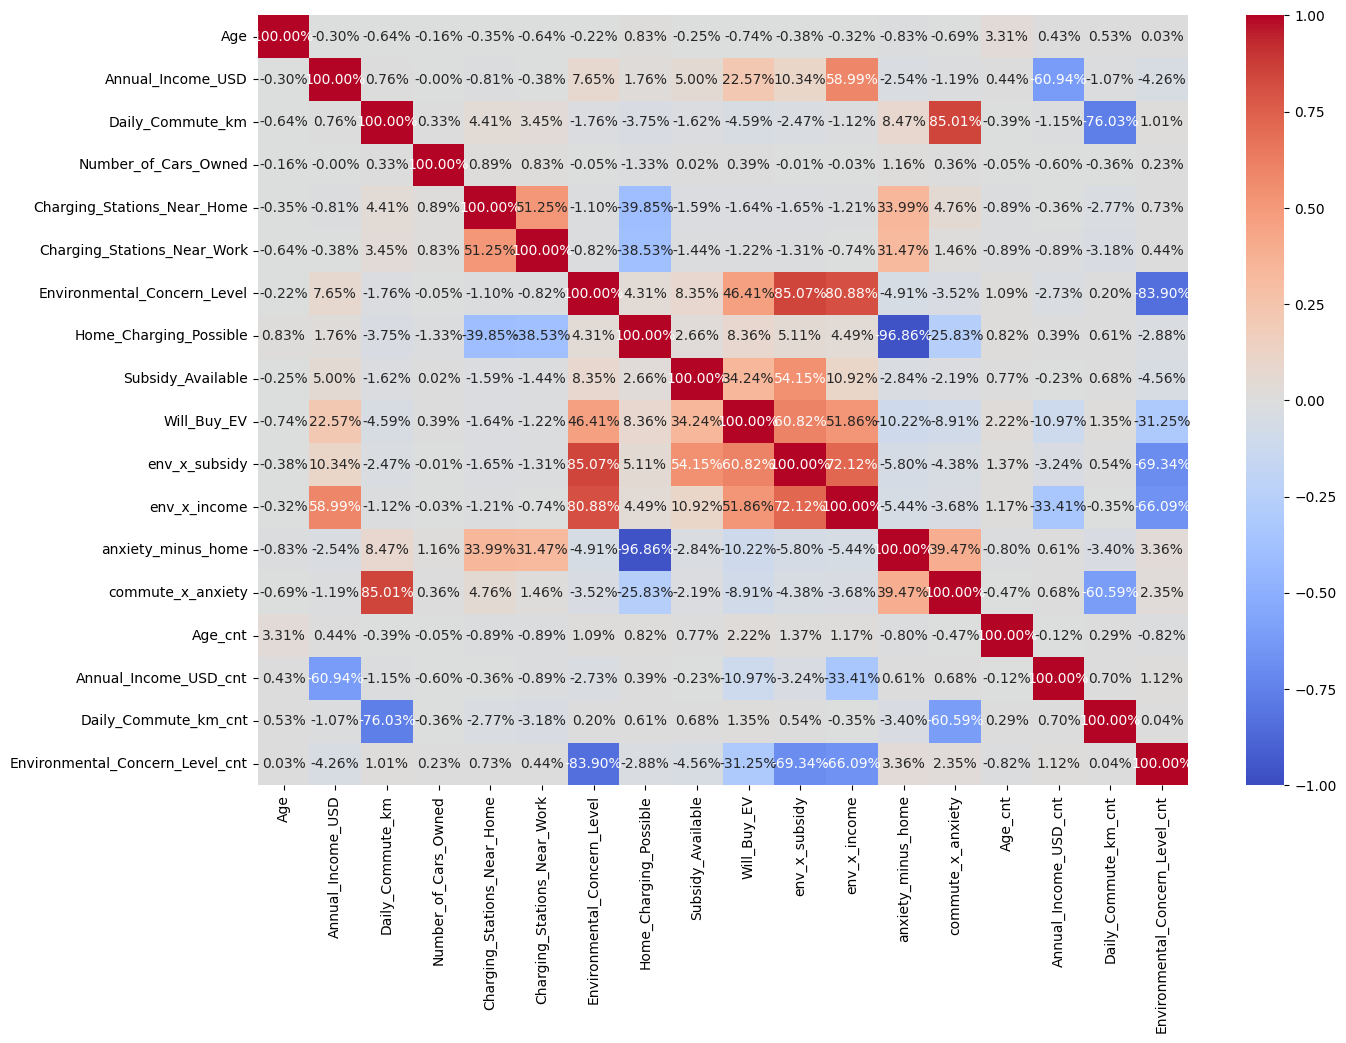

In [12]:
# Correlação

corr_matx = df[numeric_features].corr()
plt.figure(figsize=(15,10))
sns.heatmap(
    corr_matx,
    vmin=-1,
    vmax=1,
    cmap='coolwarm',
    annot=True,
    fmt='.2%'
)

In [13]:
dados_corr = dict(corr_matx['Will_Buy_EV'].sort_values(ascending=False))
dados_corr

{'Will_Buy_EV': np.float64(1.0),
 'env_x_subsidy': np.float64(0.608224333667483),
 'env_x_income': np.float64(0.5186195741886035),
 'Environmental_Concern_Level': np.float64(0.4640790214951325),
 'Subsidy_Available': np.float64(0.3423816080170018),
 'Annual_Income_USD': np.float64(0.22572928904817982),
 'Home_Charging_Possible': np.float64(0.08358430326301583),
 'Age_cnt': np.float64(0.02224869676993909),
 'Daily_Commute_km_cnt': np.float64(0.013485852228838174),
 'Number_of_Cars_Owned': np.float64(0.0038957695323481585),
 'Age': np.float64(-0.007449639416710484),
 'Charging_Stations_Near_Work': np.float64(-0.012228746950191547),
 'Charging_Stations_Near_Home': np.float64(-0.0163531919732682),
 'Daily_Commute_km': np.float64(-0.04586582995300081),
 'commute_x_anxiety': np.float64(-0.08914037981827257),
 'anxiety_minus_home': np.float64(-0.10223951772573737),
 'Annual_Income_USD_cnt': np.float64(-0.10972943506986876),
 'Environmental_Concern_Level_cnt': np.float64(-0.31245006194471125)}

In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 955236 entries, 0 to 286570
Data columns (total 22 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Age                              955236 non-null  int64  
 1   Annual_Income_USD                955236 non-null  float64
 2   Daily_Commute_km                 955236 non-null  float64
 3   Number_of_Cars_Owned             955236 non-null  int64  
 4   Charging_Stations_Near_Home      955236 non-null  int64  
 5   Charging_Stations_Near_Work      955236 non-null  int64  
 6   Environmental_Concern_Level      955236 non-null  float64
 7   Gender                           955236 non-null  str    
 8   City_Type                        955236 non-null  str    
 9   Current_Car_Type                 955236 non-null  str    
 10  Home_Charging_Possible           955236 non-null  int64  
 11  Subsidy_Available                955236 non-null  int64  
 12  Range_Anxiety_Leve

## Pré-Processamento

In [15]:
features_to_scaler = df.select_dtypes(include=['number']).columns
features_to_scaler

Index(['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Environmental_Concern_Level', 'Home_Charging_Possible',
       'Subsidy_Available', 'Will_Buy_EV', 'env_x_subsidy', 'env_x_income',
       'anxiety_minus_home', 'commute_x_anxiety', 'Age_cnt',
       'Annual_Income_USD_cnt', 'Daily_Commute_km_cnt',
       'Environmental_Concern_Level_cnt'],
      dtype='str')

In [16]:
features_to_scaler = [c for c in df.select_dtypes(include=['number']).columns if c != 'Will_Buy_EV']
features_to_scaler

['Age',
 'Annual_Income_USD',
 'Daily_Commute_km',
 'Number_of_Cars_Owned',
 'Charging_Stations_Near_Home',
 'Charging_Stations_Near_Work',
 'Environmental_Concern_Level',
 'Home_Charging_Possible',
 'Subsidy_Available',
 'env_x_subsidy',
 'env_x_income',
 'anxiety_minus_home',
 'commute_x_anxiety',
 'Age_cnt',
 'Annual_Income_USD_cnt',
 'Daily_Commute_km_cnt',
 'Environmental_Concern_Level_cnt']

In [17]:
features_to_one_hot = df.select_dtypes(include=['str']).columns
features_to_one_hot

Index(['Gender', 'City_Type', 'Current_Car_Type', 'Range_Anxiety_Level'], dtype='str')

In [18]:
preprocessing = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),features_to_scaler),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_to_one_hot)
    ],
    remainder='passthrough'
)

new_data = preprocessing.fit_transform(df)

names = preprocessing.get_feature_names_out()

new_df = pd.DataFrame(data=new_data,columns=names)
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 955236 entries, 0 to 955235
Data columns (total 31 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   num__Age                              955236 non-null  float64
 1   num__Annual_Income_USD                955236 non-null  float64
 2   num__Daily_Commute_km                 955236 non-null  float64
 3   num__Number_of_Cars_Owned             955236 non-null  float64
 4   num__Charging_Stations_Near_Home      955236 non-null  float64
 5   num__Charging_Stations_Near_Work      955236 non-null  float64
 6   num__Environmental_Concern_Level      955236 non-null  float64
 7   num__Home_Charging_Possible           955236 non-null  float64
 8   num__Subsidy_Available                955236 non-null  float64
 9   num__env_x_subsidy                    955236 non-null  float64
 10  num__env_x_income                     955236 non-null  float64
 11  num__anxiet

## Divisão Treino Teste e validação

In [19]:
df_training = new_df[:len(df_train)]
df_testing = new_df[len(df_train):]

In [20]:
df_testing.info()

<class 'pandas.DataFrame'>
RangeIndex: 286571 entries, 668665 to 955235
Data columns (total 31 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   num__Age                              286571 non-null  float64
 1   num__Annual_Income_USD                286571 non-null  float64
 2   num__Daily_Commute_km                 286571 non-null  float64
 3   num__Number_of_Cars_Owned             286571 non-null  float64
 4   num__Charging_Stations_Near_Home      286571 non-null  float64
 5   num__Charging_Stations_Near_Work      286571 non-null  float64
 6   num__Environmental_Concern_Level      286571 non-null  float64
 7   num__Home_Charging_Possible           286571 non-null  float64
 8   num__Subsidy_Available                286571 non-null  float64
 9   num__env_x_subsidy                    286571 non-null  float64
 10  num__env_x_income                     286571 non-null  float64
 11  num__a

In [21]:
df_testing = df_testing.drop(columns=['remainder__Will_Buy_EV'])
df_testing.info()

<class 'pandas.DataFrame'>
RangeIndex: 286571 entries, 668665 to 955235
Data columns (total 30 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   num__Age                              286571 non-null  float64
 1   num__Annual_Income_USD                286571 non-null  float64
 2   num__Daily_Commute_km                 286571 non-null  float64
 3   num__Number_of_Cars_Owned             286571 non-null  float64
 4   num__Charging_Stations_Near_Home      286571 non-null  float64
 5   num__Charging_Stations_Near_Work      286571 non-null  float64
 6   num__Environmental_Concern_Level      286571 non-null  float64
 7   num__Home_Charging_Possible           286571 non-null  float64
 8   num__Subsidy_Available                286571 non-null  float64
 9   num__env_x_subsidy                    286571 non-null  float64
 10  num__env_x_income                     286571 non-null  float64
 11  num__a

In [22]:
X = df_training.drop(columns=['remainder__Will_Buy_EV'])
y = df_training['remainder__Will_Buy_EV']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True,stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.3, random_state=42, shuffle=True,stratify=y_temp)

print(X_train.shape, X_val.shape, X_test.shape)

(468065, 30) (140420, 30) (60180, 30)


In [23]:
# Parâmetros modelo

params = {
    'n_estimators': 1000,
    'max_depth': 9,
    'eval_metric': 'auc',
    'learning_rate': 0.09918802139540925,
    'subsample': 0.6684329833808584,
    'colsample_bytree': 0.9151036654152414,
    'gamma': 0.14911870890152207,
    'reg_alpha': 0.10085071428350272,
    'reg_lambda': 0.6724424529145199,
    'min_child_weight': 2,
    'n_jobs': -1
}

In [24]:
skf = StratifiedKFold(n_splits=5)

results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

    xgb_cv = XGBClassifier(**params)
    xgb_cv.fit(X_tr, y_tr,
            verbose = False)

    y_pred = xgb_cv.predict_proba(X_va)[:, 1]
    acc = roc_auc_score(y_va, y_pred)
    results.append(acc)
    print(f"Fold {fold}: roc_auc = {acc:.4f}")

Fold 1: roc_auc = 0.9354
Fold 2: roc_auc = 0.9348
Fold 3: roc_auc = 0.9339
Fold 4: roc_auc = 0.9349
Fold 5: roc_auc = 0.9341


In [25]:
np.mean(results)

np.float64(0.9346348719705899)

In [26]:
xgb_clf = XGBClassifier(**params,early_stopping_rounds=10)

xgb_clf.fit(X_train, y_train,                    
            eval_set = [(X_val,y_val)])

[0]	validation_0-auc:0.93813
[1]	validation_0-auc:0.93920
[2]	validation_0-auc:0.93972
[3]	validation_0-auc:0.93998
[4]	validation_0-auc:0.94008
[5]	validation_0-auc:0.94011
[6]	validation_0-auc:0.93900
[7]	validation_0-auc:0.93935
[8]	validation_0-auc:0.93962
[9]	validation_0-auc:0.93980
[10]	validation_0-auc:0.93997
[11]	validation_0-auc:0.94010
[12]	validation_0-auc:0.94016
[13]	validation_0-auc:0.94028
[14]	validation_0-auc:0.94030
[15]	validation_0-auc:0.94037
[16]	validation_0-auc:0.94042
[17]	validation_0-auc:0.94044
[18]	validation_0-auc:0.94048
[19]	validation_0-auc:0.94052
[20]	validation_0-auc:0.94055
[21]	validation_0-auc:0.94058
[22]	validation_0-auc:0.94063
[23]	validation_0-auc:0.94069
[24]	validation_0-auc:0.94071
[25]	validation_0-auc:0.94072
[26]	validation_0-auc:0.94073
[27]	validation_0-auc:0.94075
[28]	validation_0-auc:0.94076
[29]	validation_0-auc:0.94077
[30]	validation_0-auc:0.94078
[31]	validation_0-auc:0.94080
[32]	validation_0-auc:0.94082
[33]	validation_0-au

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9151036654152414
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

In [27]:
y_pred_probs = xgb_clf.predict_proba(X_test)[:,1]
y_pred_probs

array([1.0922554e-02, 5.6877208e-01, 7.5659609e-01, ..., 2.6636252e-01,
       3.2927888e-04, 3.1525588e-01], shape=(60180,), dtype=float32)

## Avaliar métricas

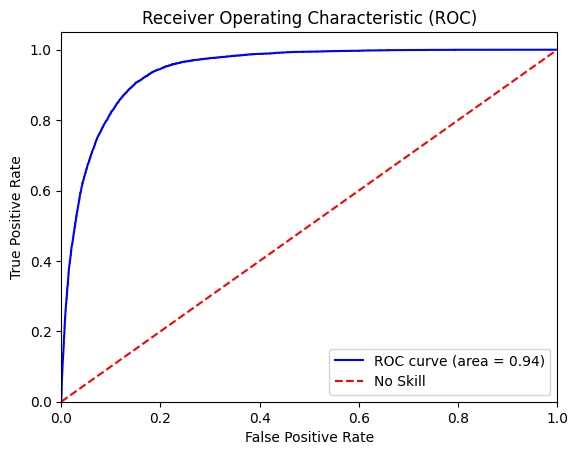

In [28]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(
    fpr, tpr, color='blue', label='ROC curve (area = %0.2f)' % roc_auc
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

In [29]:
y_pred = xgb_clf.predict(X_test)

In [30]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94     49670
         1.0       0.73      0.67      0.70     10510

    accuracy                           0.90     60180
   macro avg       0.83      0.81      0.82     60180
weighted avg       0.90      0.90      0.90     60180



In [31]:
names = ['No', 'Yes']
names

['No', 'Yes']

<Axes: >

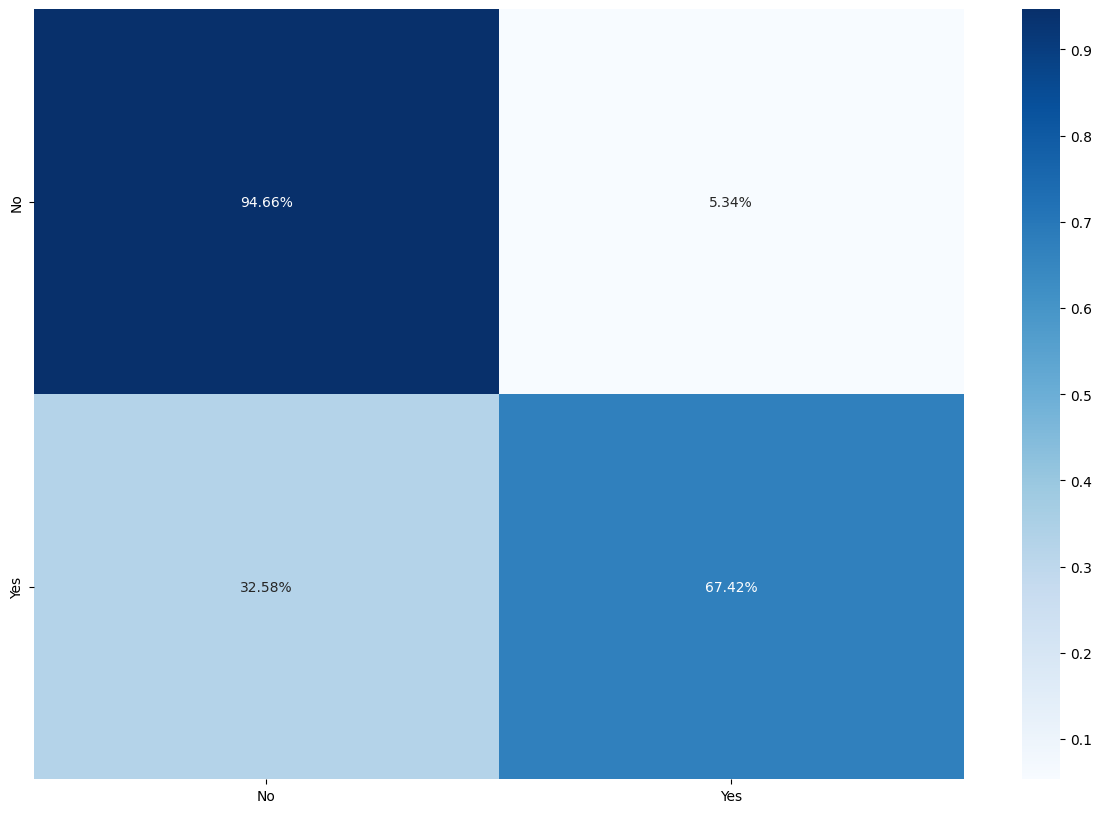

In [32]:
cfs_matrx = confusion_matrix(y_test,y_pred, normalize='true')
plt.figure(figsize=(15,10))

sns.heatmap(
    data=cfs_matrx,
    cmap='Blues',
    annot=True,
    fmt='.2%',
    yticklabels=names,
    xticklabels=names
)

## Submission

In [33]:
preds_final = xgb_clf.predict_proba(df_testing)[:,1]
preds_final

array([0.01726807, 0.01114231, 0.00357926, ..., 0.00212644, 0.00055308,
       0.00026411], shape=(286571,), dtype=float32)

In [34]:
df_result = pd.DataFrame({
    "id":ids,
    "Will_Buy_EV":preds_final
})

df_result.to_csv('submission.csv', index=False)